In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Load the S&P 500 data
data_path = r"C:\Users\62609\Downloads\S&P 500 Historical Data.csv"
df = pd.read_csv(data_path)

# Display the first few rows to check the data structure
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,06/13/2025,"5,976.97","6,000.56","6,026.16","5,963.21",NaN,-1.13%
1,06/12/2025,"6,045.26","6,009.90","6,045.43","6,003.88",NaN,0.38%
2,06/11/2025,"6,022.24","6,049.38","6,059.40","6,002.32",NaN,-0.27%
3,06/10/2025,"6,038.81","6,009.91","6,043.01","6,000.28",NaN,0.55%
4,06/09/2025,"6,005.88","6,004.63","6,021.31","5,994.18",NaN,0.09%


In [2]:
# Convert 'Date' to datetime, sort by date (ascending)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Remove commas and convert 'Price' to float
df['Price'] = df['Price'].astype(str).str.replace(',', '')
df['Price'] = df['Price'].astype(float)

# Set 'Date' as the DataFrame index for easier plotting
df.set_index('Date', inplace=True)


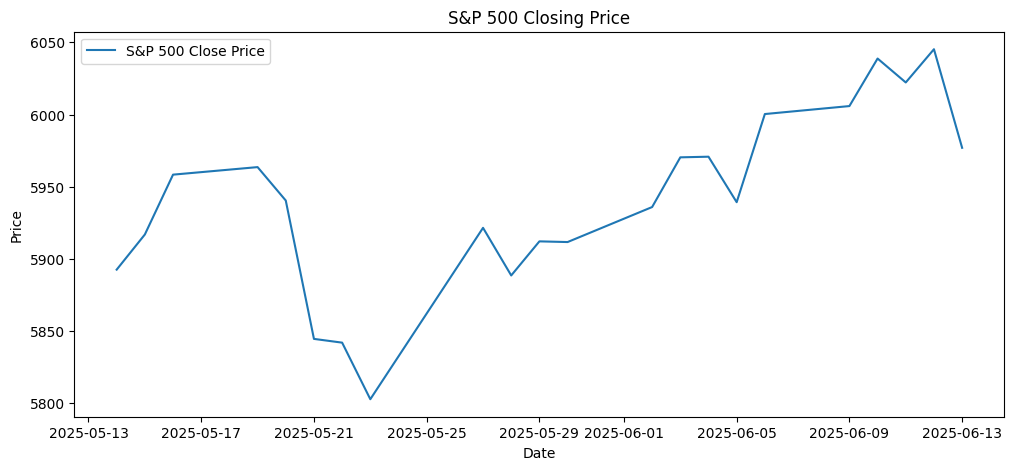

In [3]:
# Plot the original closing price series
plt.figure(figsize=(12, 5))
plt.plot(df['Price'], label='S&P 500 Close Price')
plt.title('S&P 500 Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


In [4]:
# ADF test on the original price series
result_price = adfuller(df['Price'].dropna())
print('ADF Statistic (original series): %.4f' % result_price[0])
print('p-value (original series): %.6f' % result_price[1])

# Interpret result
if result_price[1] < 0.05:
    print("The original series is stationary (no unit root).")
else:
    print("The original series is non-stationary (unit root present).")


ADF Statistic (original series): -1.7078
p-value (original series): 0.427103
The original series is non-stationary (unit root present).


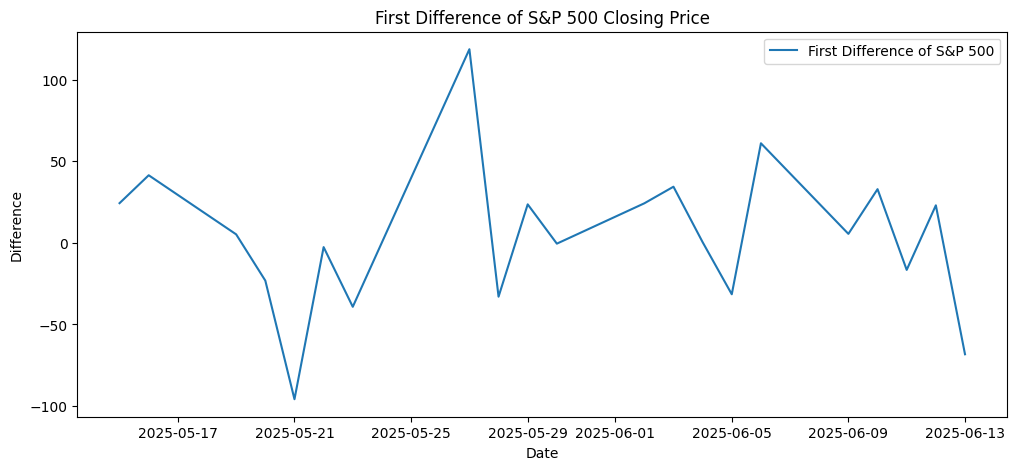

In [5]:
# Calculate and plot the first difference (price change)
df['Price_diff'] = df['Price'].diff()

plt.figure(figsize=(12, 5))
plt.plot(df['Price_diff'], label='First Difference of S&P 500')
plt.title('First Difference of S&P 500 Closing Price')
plt.xlabel('Date')
plt.ylabel('Difference')
plt.legend()
plt.show()


In [6]:
# ADF test on the first-differenced series
result_diff = adfuller(df['Price_diff'].dropna())
print('ADF Statistic (first difference): %.4f' % result_diff[0])
print('p-value (first difference): %.6f' % result_diff[1])

# Interpret result
if result_diff[1] < 0.05:
    print("The differenced series is stationary (no unit root).")
else:
    print("The differenced series is still non-stationary (unit root present).")


ADF Statistic (first difference): -5.1243
p-value (first difference): 0.000013
The differenced series is stationary (no unit root).
